In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Parametres du processus d'Ornstein-Uhlenbeck
# dX_t = theta*(mu - X_t)*dt + sigma*dW_t
theta = 1.0
mu    = 10.0
sigma = 3.0
X0    = 0.0
T     = 1.0

# Coefficients a et b de l'EDS
a = lambda x: theta * (mu - x)
b = lambda x: sigma
b_prime = lambda x: 0.0  # b ne depend pas de x => terme Milstein nul

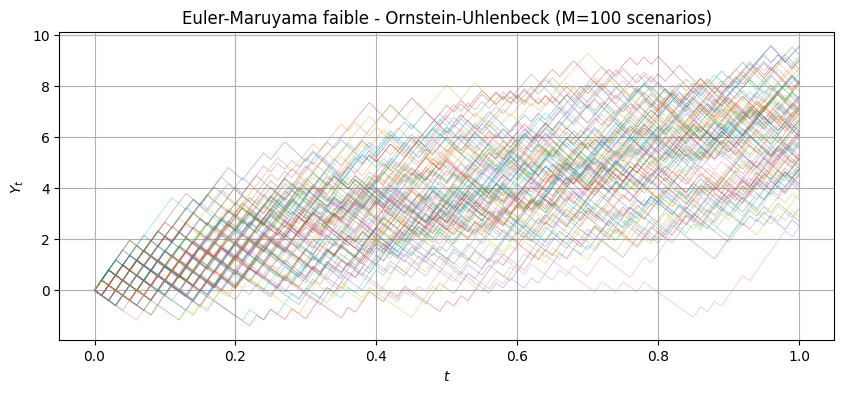

In [23]:
# Question 1 : schema d'Euler-Maruyama FAIBLE (exercice 4.4)
# Y_{n+1} = Y_n + a(Y_n)*h + b(Y_n)*xi_n*sqrt(h)
# avec xi_n = +1 ou -1 avec probabilite 1/2 (au lieu de N(0,1))

N  = 100
M  = 100
h  = T / N

# xi_n in {-1, +1} : on tire 0 ou 1 puis on convertit
Xi = 2 * np.random.randint(0, 2, (M, N)) - 1  # shape (M, N)

Y_EM = np.zeros((M, N + 1))
Y_EM[:, 0] = X0

for n in range(N):
    Y_EM[:, n+1] = Y_EM[:, n] + a(Y_EM[:, n]) * h + b(Y_EM[:, n]) * Xi[:, n] * np.sqrt(h)

t = np.linspace(0, T, N + 1)

plt.figure(figsize=(10, 4))
for i in range(M):
    plt.plot(t, Y_EM[i], alpha=0.5, linewidth=0.5)
plt.xlabel(r'$t$')
plt.ylabel(r'$Y_t$')
plt.title(f'Euler-Maruyama faible - Ornstein-Uhlenbeck (M={M} scenarios)')
plt.grid(True)
plt.show()

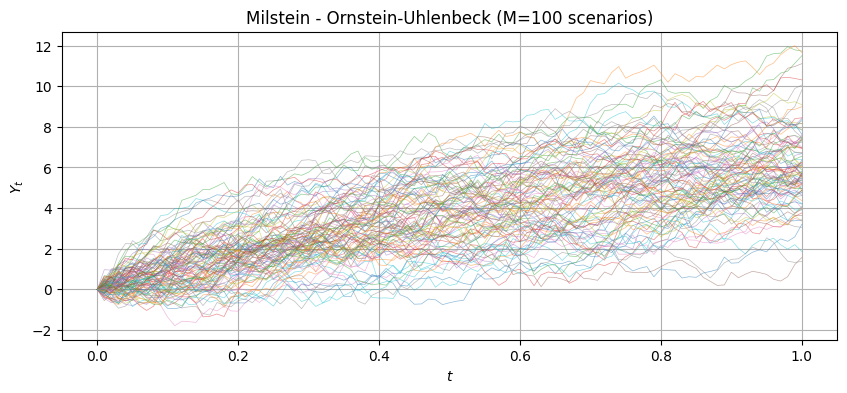

In [22]:
# Question 2 : schema de Milstein
# Y_{n+1} = Y_n + a(Y_n)*h + b(Y_n)*DW_n + (1/2)*b(Y_n)*b'(Y_n)*(DW_n^2 - h)
# Ici b'(x) = 0 donc Milstein = Euler-Maruyama STANDARD (increments gaussiens)
# On utilise quand meme des DW_n ~ N(0,h) pour montrer la structure generale

DW = np.random.normal(0, np.sqrt(h), (M, N))  # increments browniens

Y_M = np.zeros((M, N + 1))
Y_M[:, 0] = X0

for n in range(N):
    bn = b(Y_M[:, n])
    bp = b_prime(Y_M[:, n])
    Y_M[:, n+1] = (Y_M[:, n] + a(Y_M[:, n]) * h + bn * DW[:, n] + 0.5 * bn * bp * (DW[:, n]**2 - h))

plt.figure(figsize=(10, 4))
for i in range(M):
    plt.plot(t, Y_M[i], alpha=0.5, linewidth=0.5)
plt.xlabel(r'$t$')
plt.ylabel(r'$Y_t$')
plt.title(f'Milstein - Ornstein-Uhlenbeck (M={M} scenarios)')
plt.grid(True)
plt.show()

In [24]:
# Solution exacte du processus d'Ornstein-Uhlenbeck (formule de variation de la constante)
# X_t = X_0 * e^{-theta*t} + mu*(1 - e^{-theta*t}) + sigma * e^{-theta*t} * int_0^t e^{theta*s} dW_s
# Pour simuler exactement : X_{n+1} | X_n ~ N(m_n, v_n^2) avec
#   m_n = X_n * e^{-theta*h} + mu*(1 - e^{-theta*h})
#   v_n^2 = sigma^2 / (2*theta) * (1 - e^{-2*theta*h})

e  = np.exp(-theta * h)
m_coeff = mu * (1 - e)
v = sigma * np.sqrt((1 - np.exp(-2 * theta * h)) / (2 * theta))

def exact_OU(M_mc, N_steps):
    h_loc = T / N_steps
    e_loc = np.exp(-theta * h_loc)
    m_loc = mu * (1 - e_loc)
    v_loc = sigma * np.sqrt((1 - np.exp(-2 * theta * h_loc)) / (2 * theta))
    X = np.zeros((M_mc, N_steps + 1))
    X[:, 0] = X0
    Z = np.random.normal(0, 1, (M_mc, N_steps))
    for n in range(N_steps):
        X[:, n+1] = e_loc * X[:, n] + m_loc + v_loc * Z[:, n]
    return X

def EM_OU(M_mc, N_steps):
    h_loc = T / N_steps
    DW_loc = np.random.normal(0, np.sqrt(h_loc), (M_mc, N_steps))
    Y = np.zeros((M_mc, N_steps + 1))
    Y[:, 0] = X0
    for n in range(N_steps):
        Y[:, n+1] = Y[:, n] + a(Y[:, n]) * h_loc + b(Y[:, n]) * DW_loc[:, n]
    return Y

def Milstein_OU(M_mc, N_steps):
    h_loc = T / N_steps
    DW_loc = np.random.normal(0, np.sqrt(h_loc), (M_mc, N_steps))
    Y = np.zeros((M_mc, N_steps + 1))
    Y[:, 0] = X0
    for n in range(N_steps):
        bn = b(Y[:, n])
        bp = b_prime(Y[:, n])
        Y[:, n+1] = (Y[:, n] + a(Y[:, n]) * h_loc + bn * DW_loc[:, n] + 0.5 * bn * bp * (DW_loc[:, n]**2 - h_loc))
    return Y

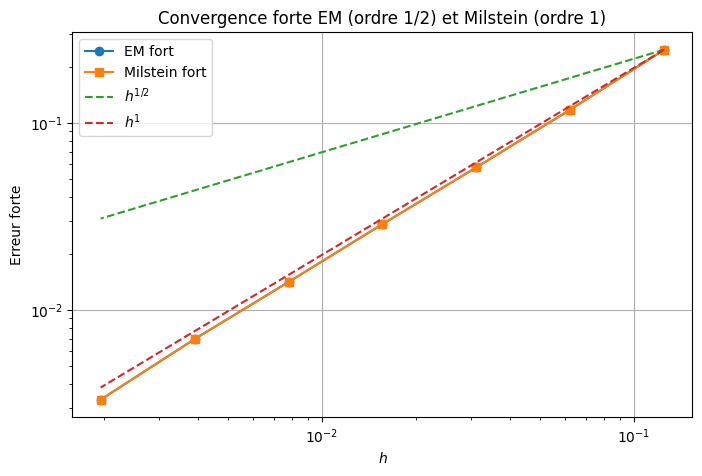

In [34]:
# Question 3a : convergence FORTE
# Erreur forte : E[|X(T) - Y_N|]  (Def. 4.19)
# On compare le schema numerique a la solution exacte sur les MEMES increments browniens
# => on genere d'abord les increments fins, puis on les sous-echantillonne

# Pour comparer sur memes trajectoires : on travaille a pas fin N_ref
# et on sous-echantillonne pour les N_steps grossiers

N_ref  = 2**13
M_fort = 500
N_list = [2**k for k in range(3, 10)]   # 8, 16, ..., 512

# Increments browniens fins
h_ref = T / N_ref
dW_ref = np.random.normal(0, np.sqrt(h_ref), (M_fort, N_ref))  # (M, N_ref)

# Solution de reference : EM sur la grille fine (approxime la solution exacte)
X_ref = np.zeros((M_fort, N_ref + 1))
X_ref[:, 0] = X0
for n in range(N_ref):
    X_ref[:, n+1] = X_ref[:, n] + a(X_ref[:, n]) * h_ref + b(X_ref[:, n]) * dW_ref[:, n]
X_T_ref = X_ref[:, -1]

err_forte_EM = []
err_forte_M  = []

for N_s in N_list:
    ratio = N_ref // N_s
    h_s   = T / N_s

    # Sous-echantillonnage des increments browniens
    dW_s = dW_ref.reshape(M_fort, N_s, ratio).sum(axis=2)  # (M, N_s)

    # EM grossier sur memes increments
    Y_em = np.zeros((M_fort, N_s + 1));  Y_em[:, 0] = X0
    Y_mi = np.zeros((M_fort, N_s + 1));  Y_mi[:, 0] = X0

    for n in range(N_s):
        # EM
        Y_em[:, n+1] = Y_em[:, n] + a(Y_em[:, n]) * h_s + b(Y_em[:, n]) * dW_s[:, n]
        # Milstein
        bn = b(Y_mi[:, n]);  bp = b_prime(Y_mi[:, n])
        Y_mi[:, n+1] = (Y_mi[:, n] + a(Y_mi[:, n]) * h_s
                        + bn * dW_s[:, n]
                        + 0.5 * bn * bp * (dW_s[:, n]**2 - h_s))

    err_forte_EM.append(np.mean(np.abs(Y_em[:, -1] - X_T_ref)))
    err_forte_M.append( np.mean(np.abs(Y_mi[:, -1] - X_T_ref)))

h_list = [T / N_s for N_s in N_list]

# Courbes theoriques
C_em = err_forte_EM[0] / h_list[0]**0.5
C_mi = err_forte_M[0]  / h_list[0]**1.0

plt.figure(figsize=(8, 5))
plt.loglog(h_list, err_forte_EM, 'o-',  label='EM fort')
plt.loglog(h_list, err_forte_M,  's-',  label='Milstein fort')
plt.loglog(h_list, C_em * np.array(h_list)**0.5, '--', label=r'$h^{1/2}$')
plt.loglog(h_list, C_mi * np.array(h_list)**1.0, '--', label=r'$h^{1}$')
plt.xlabel(r'$h$')
plt.ylabel('Erreur forte')
plt.title('Convergence forte EM (ordre 1/2) et Milstein (ordre 1)')
plt.legend()
plt.grid(True)
plt.show()

E[X_T] exact = 6.321206


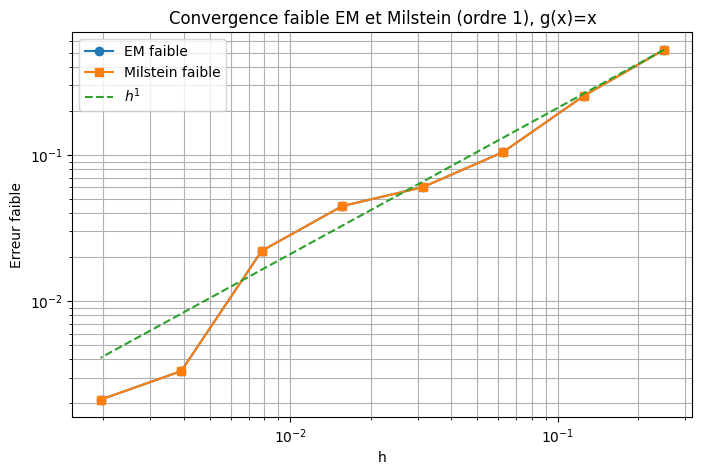

In [14]:
# Question 3b : convergence FAIBLE
# Erreur faible : |E[g(X(T))] - E[g(Y_N)]|  (Def. 4.20)
# Fonction test : g(x) = x  (moment d'ordre 1, suffisamment reguliere)
# Valeur exacte : E[X_T] = X0 * e^{-theta*T} + mu*(1 - e^{-theta*T})

g = lambda x: x   # fonction test
E_exact = X0 * np.exp(-theta * T) + mu * (1 - np.exp(-theta * T))
print(f"E[X_T] exact = {E_exact:.6f}")

N_list_faible = [2**k for k in range(2, 10)]  # 4, 8, ..., 256
M_faible = 50000   # besoin de beaucoup de MC pour la convergence faible

err_faible_EM = []
err_faible_M  = []

for N_s in N_list_faible:
    h_s  = T / N_s
    DW_s = np.random.normal(0, np.sqrt(h_s), (M_faible, N_s))

    Y_em = np.zeros(M_faible);  Y_em[:] = X0
    Y_mi = np.zeros(M_faible);  Y_mi[:] = X0

    for n in range(N_s):
        Y_em = Y_em + a(Y_em) * h_s + b(Y_em) * DW_s[:, n]
        bn = b(Y_mi);  bp = b_prime(Y_mi)
        Y_mi = Y_mi + a(Y_mi) * h_s + bn * DW_s[:, n] + 0.5 * bn * bp * (DW_s[:, n]**2 - h_s)

    err_faible_EM.append(abs(np.mean(g(Y_em)) - E_exact))
    err_faible_M.append( abs(np.mean(g(Y_mi)) - E_exact))

h_list_f = [T / N_s for N_s in N_list_faible]

C_em_f = err_faible_EM[0] / h_list_f[0]**1.0
C_mi_f = err_faible_M[0]  / h_list_f[0]**1.0

plt.figure(figsize=(8, 5))
plt.loglog(h_list_f, err_faible_EM, 'o-', label='EM faible')
plt.loglog(h_list_f, err_faible_M,  's-', label='Milstein faible')
plt.loglog(h_list_f, C_em_f * np.array(h_list_f)**1.0, '--', label=r'$h^{1}$')
plt.xlabel('h'); plt.ylabel('Erreur faible')
plt.title(r'Convergence faible EM et Milstein (ordre 1), g(x)=x')
plt.legend(); plt.grid(True, which='both')
plt.show()